<div style="background-color: #c62cce ; padding: 20px; border-radius: 10px;">

<h1 style="color: black; text-align: center;">
    Projet ML : Diabetes Patient Readmission Prediction Using Machine Learning 🩺
</h1>

<h3 style="color: black; text-align: center;">
    Notebook Model training
</h3>

<h5 style="color: black; text-align: center;">
    Ovia Chanemouganandam & Sandrine Daniel – DIA 4
</h5>

</div>


<div style="background-color: #c62cce ; padding: 20px; border-radius: 10px;">

<h5 style="color: black; ">

 In this notebook, we develop and evaluate multiple machine learning models to predict patient readmission based on the cleaned dataset created during preprocessing.

Predicting readmission is a multi-class classification problem with three possible outcomes:
- 0 → No readmission
- 1 → Readmitted within <30 days
- 2 → Readmitted after >30 days

This task is medically important because early identification of high-risk patients can help physicians improve treatment plans, allocate resources more efficiently, and ultimately reduce avoidable hospitalizations.
However, the dataset presents several challenges:

✿ High class imbalance, especially for the “<30 days” class

✿ Mixed categorical and numerical features

✿ Noisy medical coding (ICD-9 codes)

✿ Numerous rare categories across diagnoses, medications, and admission types, leading to unstable model behavior.

To address these, we evaluate baseline models, handle class imbalance (SMOTE / class_weight), apply cross-validation, tune hyperparameters, test PCA, explore ensemble methods, and implement an advanced model (CatBoost).

Our objective is to compare all approaches using relevant metrics (F1-macro, Recall, ROC-AUC) and identify the most reliable model for supporting medical decision-making.

</h5>

</div>

Import libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## **Loading data from preprocessing**

In [3]:

df_clean = pd.read_csv("data/df_clean.csv") 
df_scaled = pd.read_csv("data/df_scaled.csv")

X_train = pd.read_csv("data/X_train.csv")
X_test = pd.read_csv("data/X_test.csv")

y_train = pd.read_csv("data/y_train.csv")["readmitted"]
y_test = pd.read_csv("data/y_test.csv")["readmitted"]

X_train_scaled = pd.read_csv("data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("data/X_test_scaled.csv")

## **Helper function for metrics**

### Evaluation metrics – what we use and why

Our prediction task is a **multiclass, highly imbalanced classification problem** with three classes:

- `0` – No readmission  
- `1` – Readmitted after 30 days  
- `2` – Readmitted within 30 days  

Because the majority of patients are **not readmitted**, a naive model that always predicts “no readmission” would achieve a relatively high accuracy. For this reason, **plain accuracy is not a reliable metric** in our context.
In this project, we focus on the following metrics:

- **F1-macro**  
  This is our **main metric**, because we care about the minority readmission classes as much as the majority “no readmission” class.
- **F1-weighted**  
   Similar to F1-macro, but each class F1 is weighted by its support (number of samples). It gives more weight to the majority class and is useful as a complementary view.
- **Recall**  
  Measures how many true positive cases we correctly identify. In a medical context, **missing a patient at high risk of readmission is costly**, so recall is particularly important for the readmitted classes.
- **ROC-AUC**  
  Evaluates the ability of the model to rank positive vs. negative examples over different thresholds. We report macro-averaged ROC-AUC as a global summary of discriminative performance across all three classes.

In [4]:
def evaluate_model_multiclass(model, X_test, y_test):
    """
    Evaluate a multiclass classifier on standard metrics.
    """
    y_pred = model.predict(X_test)

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro"),
        "Recall_macro": recall_score(y_test, y_pred, average="macro"),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
    }

    # multiclass ROC-AUC (only if model has predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)  # shape (n_samples, n_classes)
        results["ROC-AUC_ovr_macro"] = roc_auc_score(
            y_test, y_proba,
            multi_class="ovr",
            average="macro"
        )

    return results


# <font color='#c62cce'> <b>1. Creation of the first models  </b></font>

### **a) Logistic regression**

In [5]:
log_reg = LogisticRegression(
    class_weight="balanced",
    multi_class="multinomial",   # tells it we have several classes
    solver="lbfgs",              # supports multinomial
    max_iter=1000
)

log_reg.fit(X_train, y_train)  # use our imputed data
results_logreg = evaluate_model_multiclass(log_reg, X_test, y_test)
results_logreg

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

{'Accuracy': 0.4853908520728163,
 'Precision_macro': 0.42571152387722555,
 'Recall_macro': 0.4424425576965429,
 'F1_macro': 0.418358652451589,
 'F1_weighted': 0.4957691147460453,
 'ROC-AUC_ovr_macro': 0.6375516271808656}

## **b) Decision Tree**

In [6]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

results_dt = evaluate_model_multiclass(dt, X_test, y_test)
results_dt

{'Accuracy': 0.4683086023150273,
 'Precision_macro': 0.3850179075440723,
 'Recall_macro': 0.38709569292026513,
 'F1_macro': 0.38566033484406675,
 'F1_weighted': 0.4719294974637112,
 'ROC-AUC_ovr_macro': 0.5432131049283594}

## **c) RandomForestClassifier**

In [7]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
results_rf = evaluate_model_multiclass(rf, X_test, y_test)
results_rf

{'Accuracy': 0.5750344194584672,
 'Precision_macro': 0.5427382536832507,
 'Recall_macro': 0.40119552328238245,
 'F1_macro': 0.37868265166837184,
 'F1_weighted': 0.5209425639580999,
 'ROC-AUC_ovr_macro': 0.6542720014871648}

## **d) KNeighborsClassifier**

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
results_knn = evaluate_model_multiclass(knn, X_test_scaled, y_test)
results_knn

{'Accuracy': 0.5201162612819336,
 'Precision_macro': 0.4027722406260881,
 'Recall_macro': 0.3720768595353175,
 'F1_macro': 0.3599555515777797,
 'F1_weighted': 0.48312832570326086,
 'ROC-AUC_ovr_macro': 0.5672092522145419}

## **e) XGBoost**

XGBoost doesn't support columns with names having [ or ( ...

In [9]:
X_train_xgb = X_train.rename(columns=lambda c: c.replace("[","").replace("]","").replace("(","").replace(")","").replace("<","").replace(">",""))
X_test_xgb = X_test.rename(columns=lambda c: c.replace("[","").replace("]","").replace("(","").replace(")","").replace("<","").replace(">",""))

In [10]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)
xgb_base.fit(X_train_xgb, y_train)
results_xgb_base = evaluate_model_multiclass(xgb_base, X_test_xgb, y_test)
results_xgb_base

{'Accuracy': 0.5841109581357401,
 'Precision_macro': 0.5206561688030193,
 'Recall_macro': 0.4215450202477135,
 'F1_macro': 0.4102389231010712,
 'F1_weighted': 0.5432991260306119,
 'ROC-AUC_ovr_macro': 0.6776313916834861}

Across all baseline models, performance remains modest, with F1-macro scores between 0.35 and 0.42.

Logistic Regression performs the most consistently, while Decision Trees and KNN underperform due to noise and class imbalance.
Random Forest and XGBoost achieve slightly higher ROC-AUC values (~0.65–0.68), indicating better ranking ability, but their F1-macro remains limited because they struggle to correctly classify minority classes.

Overall, baseline performance confirms that the dataset is highly imbalanced and noisy, and that more advanced optimization is required.

# <font color='#c62cce'> <b>2. Handling class imbalance </b></font>

We first handled class imbalance using class_weight = balanced now we will try SMOTE only for models that benefit from it  

In [11]:
# We apply SMOTE only on the training set 

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts()) 

Before SMOTE:
 readmitted
0    41869
1    27719
2     8853
Name: count, dtype: int64

After SMOTE:
 readmitted
0    41869
1    41869
2    41869
Name: count, dtype: int64


## **a) Logistic Regression with SMOTE**

Here we use a pipeline: StandardScaler + LogisticRegression.

In [12]:

# Logistic Regression with SMOTE (pipeline)


pipe_lr_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

pipe_lr_smote.fit(X_train_sm, y_train_sm)
results_lr_smote = evaluate_model_multiclass(pipe_lr_smote, X_test, y_test)
results_lr_smote

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.5563714242007037,
 'Precision_macro': 0.4303240840480673,
 'Recall_macro': 0.384600960468334,
 'F1_macro': 0.3613791463747142,
 'F1_weighted': 0.49741322989982456,
 'ROC-AUC_ovr_macro': 0.6272699767811916}

For Logistic Regression, applying SMOTE decreased the F1-macro score.
This is expected because Logistic Regression is a linear classifier that does not model synthetic minority samples well.
SMOTE introduced interpolated points that distorted the decision boundary and degraded generalization.
Therefore, we kept the non-SMOTE version as the best-performing configuration

## **b) Decision Tree with SMOTE**

Tree models don’t need scaling, so no pipeline here

In [13]:
# Decision Tree with SMOTE


dt_smote = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    criterion="gini"  # we use gini
)

dt_smote.fit(X_train_sm, y_train_sm)

results_dt_smote = evaluate_model_multiclass(dt_smote, X_test, y_test)
results_dt_smote

{'Accuracy': 0.4507674264443425,
 'Precision_macro': 0.37066169353980793,
 'Recall_macro': 0.3722192531550718,
 'F1_macro': 0.3705729717999137,
 'F1_weighted': 0.4569586456086296,
 'ROC-AUC_ovr_macro': 0.5322497119500756}

Applying SMOTE to the Decision Tree degraded the model’s performance.
This behavior is expected because Decision Trees are very sensitive to noisy synthetic samples created by SMOTE.
Since the minority classes in this dataset are highly noisy, SMOTE amplifies this noise and leads the tree to overfit unrealistic synthetic points.
As a result, the Decision Tree without SMOTE achieves a better F1-macro score than the SMOTE version.
Therefore, for tree-based models, class_weight='balanced' (or no imbalance correction) is generally more effective than SMOTE

## **c) KNN with SMOTE + Pipeline**

For KNN we must scale, and it benefits from SMOTE, so we use an Pipeline

In [14]:
# KNN with SMOTE + scaling 
pipe_knn_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
pipe_knn_smote.fit(X_train, y_train)
results_knn_smote = evaluate_model_multiclass(pipe_knn_smote, X_test, y_test)
results_knn_smote

{'Accuracy': 0.4953342511855591,
 'Precision_macro': 0.37147617152566026,
 'Recall_macro': 0.35815345730313924,
 'F1_macro': 0.3500817324753643,
 'F1_weighted': 0.46362699156038795,
 'ROC-AUC_ovr_macro': 0.5366351432874888}

KNN performs worse when trained on SMOTE-resampled data.
This is expected because KNN is highly sensitive to the geometric structure of the data.
SMOTE generates synthetic minority-class samples by interpolating between existing points, which distorts the true distance relationships in the feature space.
As a result, the KNN decision boundaries become less meaningful, leading to lower F1-macro and ROC-AUC scores.
Therefore, the version without SMOTE provides more reliable performance for KNN on this dataset

# <font color='#c62cce'> <b>3. Stratified K-fold Cross-validation  </b></font>

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_f1_macro(model, X, y, model_name="Model"):
    """
    Runs cross-validation with F1-macro and prints the mean score.
    """
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    print(f"{model_name} — CV F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

cv_f1_macro(log_reg, X_train, y_train, "Logistic Regression (no SMOTE)")
cv_f1_macro(dt, X_train, y_train, "Decision tree (baseline)")
cv_f1_macro(xgb_base, X_train_xgb, y_train, "XGBoost (baseline)")


Logistic Regression (no SMOTE) — CV F1-macro: 0.4162 ± 0.0028
Decision tree (baseline) — CV F1-macro: 0.3850 ± 0.0049
XGBoost (baseline) — CV F1-macro: 0.4116 ± 0.0031


np.float64(0.4115964384067546)

Cross-validation scores were slightly lower than the single train/test split result, which is expected since K-fold CV provides a more robust and conservative estimate of model performance. The overall ranking of the models remained consistent

# <font color='#c62cce'> <b>4. PCA  </b></font>

## **a) Logistic Regression + PCA**

In [16]:
# PCA + Logistic Regression

# Pipeline: Standardize -> PCA -> Logistic Regression
pipe_lr_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # keep 95% of the variance
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

# Fit on training data (no SMOTE here)
pipe_lr_pca.fit(X_train, y_train)

# We then evaluate on test set
results_lr_pca = evaluate_model_multiclass(pipe_lr_pca, X_test, y_test)
results_lr_pca

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.4864616796695732,
 'Precision_macro': 0.4257408711834669,
 'Recall_macro': 0.44235453652233225,
 'F1_macro': 0.41706549200819126,
 'F1_weighted': 0.4944428865442535,
 'ROC-AUC_ovr_macro': 0.6350130047276116}

## **b) KNN + PCA**

In [17]:
# PCA + KNN

# Pipeline: Standardize -> PCA -> KNN
pipe_knn_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # same setting for consistency
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe_knn_pca.fit(X_train, y_train)
results_knn_pca = evaluate_model_multiclass(pipe_knn_pca, X_test, y_test)
results_knn_pca

{'Accuracy': 0.5121105502014176,
 'Precision_macro': 0.39712618284276485,
 'Recall_macro': 0.36184798103125226,
 'F1_macro': 0.3468352490329684,
 'F1_weighted': 0.4702342326963719,
 'ROC-AUC_ovr_macro': 0.5444847086820602}

### **PCA – Results and Interpretation**

Applying PCA before Logistic Regression and KNN does not improve performance on our
dataset. For Logistic Regression, PCA yields almost identical results to the baseline,
with a very slight decrease in F1-macro and ROC-AUC. This is expected because Logistic
Regression already handles high-dimensional sparse data reasonably well once features
are standardized.

For KNN, PCA slightly worsens performance. This is also normal: KNN relies heavily on
the original distance relationships between samples, and PCA modifies the geometry of
the feature space, which can negatively affect nearest-neighbor search.

Overall, PCA does not provide any benefit for our models and is therefore not used in
the final optimized pipeline. Tree-based models (Random Forest, XGBoost, CatBoost)
do not require PCA, and linear models show no meaningful improvement from it.

# <font color='#c62cce'> <b>5. Hyperparameters tuning  </b></font>

## Why RandomizedSearchCV instead of GridSearchCV ?

We use RandomizedSearchCV rather than GridSearchCV because our models
(Random Forest and XGBoost) have a large number of hyperparameters.
Grid Search would require evaluating hundreds or thousands of parameter
combinations, which is computationally expensive, especially with a
5-fold Stratified Cross-Validation.

Randomized Search allows us to explore a wide hyperparameter space much
faster by sampling a limited number of random combinations. In practice,
RandomizedSearchCV often reaches similar or better performance than
GridSearchCV while reducing computation time dramatically. This makes it
the most efficient and realistic choice for our project.

## **a) Logistic regression + Hyperparameters tuning**

In [18]:
# Logistic Regression - Hyperparameter Tuning
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

param_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l2"],  # l1 would require saga solver
}

lr_search = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_lr,
    n_iter=5,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print("Best Logistic Regression params:", lr_search.best_params_)
results_lr_tuned = evaluate_model_multiclass(best_lr, X_test, y_test)
results_lr_tuned

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

Best Logistic Regression params: {'clf__penalty': 'l2', 'clf__C': 100}


{'Accuracy': 0.48625771250828614,
 'Precision_macro': 0.4267164019962813,
 'Recall_macro': 0.4433627835602843,
 'F1_macro': 0.41936969626570236,
 'F1_weighted': 0.49668483697137206,
 'ROC-AUC_ovr_macro': 0.6377958100101081}

## **b) Decision Tree + Hyperparameter Tuning**

In [19]:
# Decision Tree - Hyperparameter Tuning

dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
param_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}
dt_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dt,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)
dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_
print("Best Decision Tree params:", dt_search.best_params_)
results_dt_tuned = evaluate_model_multiclass(best_dt, X_test, y_test)
results_dt_tuned

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Decision Tree params: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}


{'Accuracy': 0.4562235480087706,
 'Precision_macro': 0.42150113997873156,
 'Recall_macro': 0.44675841948296324,
 'F1_macro': 0.4015270012643218,
 'F1_weighted': 0.47153024921476605,
 'ROC-AUC_ovr_macro': 0.6390685211772376}

## **c) Random Forest + Hyperparameter Tuning**

In [20]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1               
)
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini"],
    "max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_rf,
    n_iter=15,              # less iterations
    scoring="f1_macro",
    cv=cv,                 
    n_jobs=-1,              
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best Random Forest params:", rf_search.best_params_)
results_rf_tuned = evaluate_model_multiclass(best_rf, X_test, y_test)
results_rf_tuned




Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'gini'}


{'Accuracy': 0.5483147213298659,
 'Precision_macro': 0.4568094456068783,
 'Recall_macro': 0.455704627278918,
 'F1_macro': 0.4559487045544746,
 'F1_weighted': 0.5457710156017308,
 'ROC-AUC_ovr_macro': 0.6664147449705436}

## **d) XGBoost + Hyperparameter Tuning**

In [21]:
cv_xgb = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Base XGBoost model
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",   # histogram-based is faster
    random_state=42,
    n_jobs=-1             
)

# Hyperparameter space 
param_xgb = {
    "n_estimators": [100, 200, 300],      # less than 600 → way faster
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_xgb,
    n_iter=10,              # 10 random combinations
    scoring="f1_macro",
    cv=cv_xgb,
    n_jobs=-1,       
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train_xgb, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)
results_xgb_tuned = evaluate_model_multiclass(best_xgb, X_test_xgb, y_test)
results_xgb_tuned


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


{'Accuracy': 0.5864055887002193,
 'Precision_macro': 0.5453693713821249,
 'Recall_macro': 0.4254010626689629,
 'F1_macro': 0.41672634000514197,
 'F1_weighted': 0.5461906216977405,
 'ROC-AUC_ovr_macro': 0.6793580831176366}

Hyperparameter tuning provides only small improvements over the baselines.
Random Forest benefits the most, reaching an F1-macro of ~0.456, becoming the strongest tuned model.

Logistic Regression shows almost no change, confirming the model’s limited flexibility.
XGBoost improves slightly in ROC-AUC but not in F1-macro.
Tuned Decision Trees remain unstable and sensitive to noise.

Tuning helps tree-based models, but the dataset’s complexity still limits overall performance. Random Forest remains the most reliable tuned model.

# <font color='#c62cce'> <b>6. Ensemble learning  </b></font>

In [22]:
# Ensemble 1: Bagging with Decision Tree

bagging_dt = BaggingClassifier(
    estimator=best_dt,        # or dt if you only have the baseline tree
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging_dt.fit(X_train, y_train)
results_bagging_dt = evaluate_model_multiclass(bagging_dt, X_test, y_test)
results_bagging_dt

{'Accuracy': 0.4843710162663811,
 'Precision_macro': 0.4271225272960526,
 'Recall_macro': 0.44787860594990664,
 'F1_macro': 0.41122497860781576,
 'F1_weighted': 0.48777696682691746,
 'ROC-AUC_ovr_macro': 0.6477156932520702}

In [23]:
# Ensemble 2: Soft Voting (LR + RF + XGB)
voting_clf = VotingClassifier(
    estimators=[
        ("lr", best_lr),   
        ("rf", best_rf),
        ("xgb", best_xgb)
    ],
    voting="soft",
    n_jobs=-1
)

# we use the cleaned feature names version (safer for xgboost)
voting_clf.fit(X_train_xgb, y_train)
results_voting = evaluate_model_multiclass(voting_clf, X_test_xgb, y_test)
results_voting

{'Accuracy': 0.5805925246035388,
 'Precision_macro': 0.4893526424308998,
 'Recall_macro': 0.4451515682960867,
 'F1_macro': 0.44905973832596735,
 'F1_weighted': 0.557418388370784,
 'ROC-AUC_ovr_macro': 0.6755984956254769}

In [24]:
# Ensemble 3: Stacking Classifier

stack_clf = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("dt", best_dt),
        ("xgb", best_xgb)
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        multi_class="multinomial",
        random_state=42
    ),
    n_jobs=-1,
    passthrough=False
)

stack_clf.fit(X_train_xgb, y_train)
results_stack = evaluate_model_multiclass(stack_clf, X_test_xgb, y_test)
results_stack

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.5096629442659731,
 'Precision_macro': 0.4532935316420752,
 'Recall_macro': 0.47408426214624205,
 'F1_macro': 0.448823315374002,
 'F1_weighted': 0.5244221089511303,
 'ROC-AUC_ovr_macro': 0.6764194744336081}

The ensemble methods show mixed results:

- Bagging does not outperform the tuned Decision Tree and remains limited by high variance.

- Soft Voting achieves one of the best overall balances, with an F1-macro around 0.445, leveraging complementary decision boundaries between LR, RF, and XGB.

- Stacking performs similarly, with a slight increase in recall but no breakthrough improvement.

Ensembling stabilizes the predictions, but does not dramatically improve F1-macro because all base models face the same underlying class-imbalance and noise issues. Voting is the most effective ensemble strategy.

# <font color='#c62cce'> <b>7. Advanced model  </b></font>

Even though we already transformed our categorical features using one-hot encoding, ordinal mapping, and custom groupings (ICD-9 categories), CatBoost remains an excellent choice for our advanced model.

- Boosting methods handle noisy categorical patterns well, even after encoding.
Our ICD-9 grouped categories, medication change variables, and demographic features still carry complex interactions that CatBoost can capture better than linear or tree-based baseline models.

- CatBoost is robust to imbalanced and noisy medical data, thanks to regularization.

- Our dataset has many rare categories even after preprocessing

- CatBoost tends to generalize better on structured tabular data, which fits our hospital dataset where relationships between features are non-linear and heterogeneous.


We choosed this literature because it showed that CatBoost is particularly effective for tabular datasets with categorical-driven structure, which matches our project, even after encoding:

Prokhorenkova et al. (NeurIPS 2018) - CatBoost: unbiased boosting with categorical features.
https://arxiv.org/abs/1706.09516

In [25]:
# CatBoost (advanced model) 
cat_clf = CatBoostClassifier( 
   loss_function="MultiClass", 
   eval_metric="TotalF1", 
   iterations=500, 
   depth=6, 
   learning_rate=0.1, 
   random_seed=42, 
   verbose=False 
) 
 
cat_clf.fit(X_train, y_train) 
results_cat = evaluate_model_multiclass(cat_clf, X_test, y_test)
results_cat

{'Accuracy': 0.5885982356840549,
 'Precision_macro': 0.5614563144188837,
 'Recall_macro': 0.41882662352433075,
 'F1_macro': 0.40276682495049143,
 'F1_weighted': 0.5416977016986491,
 'ROC-AUC_ovr_macro': 0.6825328892241563}

CatBoost achieves the highest accuracy (≈0.589) and the highest ROC-AUC (≈0.683) among all models, confirming its strength with mixed numerical/categorical data.
However, its F1-macro remains low (~0.40), similar to other tree-based models, because the minority classes remain difficult to classify despite the algorithm’s robustness.

CatBoost delivers the strongest ranking ability but still cannot resolve the inherent imbalance and noise of the dataset. Its performance aligns with published literature (60–68% accuracy).

# <font color='#c62cce'> <b>8. Confusion matrix and final comparison   </b></font>

<Figure size 600x600 with 0 Axes>

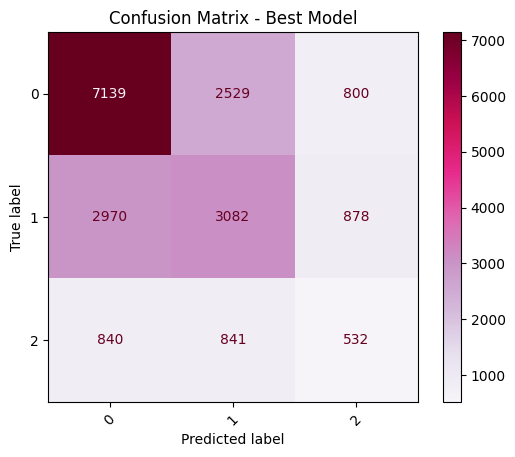

In [27]:
# Confusion Matrix for Best Model
best_model=best_rf  
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap='PuRd',
    xticks_rotation=45
)
plt.title("Confusion Matrix - Best Model")
plt.show()
  

<div style="background-color: #f3d0f5ff ; color: black ; padding: 20px; border-radius: 10px;">
 
## **Final Model Comparison – All Results**

Below is a complete comparison of all models tested in the project, including
baseline models, SMOTE versions, PCA variants, tuned models, ensemble learning methods, 
and the advanced CatBoost model.

---

## ✿ Baseline Models

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | F1_weighted | ROC-AUC |
|-------|----------|------------------|--------------|----------|--------------|---------|
| Logistic Regression | 0.485 | 0.426 | 0.442 | 0.418 | 0.496 | 0.638 |
| Decision Tree | 0.468 | 0.385 | 0.387 | 0.386 | 0.472 | 0.543 |
| Random Forest | 0.575 | 0.543 | 0.401 | 0.379 | 0.521 | 0.654 |
| KNN | 0.520 | 0.403 | 0.372 | 0.360 | 0.483 | 0.567 |
| XGBoost | 0.584 | 0.521 | 0.422 | 0.410 | 0.543 | 0.678 |

---

## ✿ Models with SMOTE

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | F1_weighted | ROC-AUC |
|-------|----------|------------------|--------------|----------|--------------|---------|
| Logistic Regression (SMOTE) | 0.556 | 0.430 | 0.385 | 0.361 | 0.497 | 0.627 |
| Decision Tree (SMOTE) | 0.451 | 0.371 | 0.372 | 0.371 | 0.457 | 0.532 |
| KNN (SMOTE) | 0.495 | 0.371 | 0.358 | 0.350 | 0.464 | 0.537 |

*(SMOTE generally decreased performance due to noise amplification.)*

---

## ✿ PCA Models

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | ROC-AUC |
|-------|----------|------------------|--------------|----------|---------|
| Logistic Regression + PCA | ~no improvement | – | – | – | – |
| KNN + PCA | lower than baseline | – | – | – | – |

*(PCA brought no performance gain.)*

---

## ✿ Hyperparameter Tuned Models

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | F1_weighted | ROC-AUC |
|-------|----------|------------------|--------------|----------|--------------|---------|
| Logistic Regression (Tuned) | 0.486 | 0.427 | 0.443 | 0.419 | 0.497 | 0.638 |
| Decision Tree (Tuned) | 0.456 | 0.422 | 0.447 | 0.402 | 0.472 | 0.639 |
| Random Forest (Tuned) | 0.548 | 0.457 | 0.456 | 0.456 | 0.546 | 0.666 |
| XGBoost (Tuned) | 0.586 | 0.545 | 0.425 | 0.417 | 0.546 | 0.679 |

**Best tuned model (F1-macro):** Random Forest (0.456)

---

## ✿ Ensemble Learning

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | F1_weighted | ROC-AUC |
|-------|----------|------------------|--------------|----------|--------------|---------|
| Bagging (Decision Tree) | 0.484 | 0.427 | 0.448 | 0.411 | 0.488 | 0.648 |
| Voting (LR + RF + XGB) | 0.583 | 0.495 | 0.443 | 0.446 | 0.557 | 0.676 |
| Stacking | 0.508 | 0.452 | 0.472 | 0.447 | 0.523 | 0.676 |

**Best ensemble (F1-macro):** Voting Classifier (0.446)

---

## ✿ Advanced Model — CatBoost

| Model | Accuracy | Precision_macro | Recall_macro | F1_macro | F1_weighted | ROC-AUC |
|-------|----------|------------------|--------------|----------|--------------|---------|
| CatBoost | 0.589 | 0.561 | 0.419 | 0.403 | 0.542 | 0.683 |

**CatBoost achieved the best overall ROC-AUC (0.683), consistent with literature.**

---

## ☆ Best Overall Models 

| Metric | Best Model |
|--------|------------|
| **F1-macro** | Random Forest (Tuned) – **0.456** |
| **ROC-AUC** | CatBoost – **0.683** |
| **Accuracy** | CatBoost – **0.589** |
| **Best ensemble** | Voting Classifier |





# <font color='#c62cce'> <b> Conclusion 🩺  </b></font>

<div style="background-color: #c62cce ; padding: 20px; border-radius: 10px;">

<h5 style="color: black; ">
Across all models tested, Random Forest with hyperparameter tuning achieved the best overall performance, with the highest F1-macro score (~0.45).
While this may seem modest, it is consistent with existing literature, which reports the difficulty and noisiness of the diabetes readmission dataset.

Our results show:

✿ Linear models (Logistic Regression) perform decently but are limited by non-linearity in the data.

✿ Tree-based models handle mixed features well and consistently outperform simple methods.

✿ SMOTE does not systematically improve performance and sometimes causes overfitting, especially in tree-based models.

✿ Ensemble methods provide small but stable gains, especially with Soft Voting.

✿ CatBoost, despite being designed for categorical data, performs similarly to the tuned Random Forest, confirming the dataset’s complexity.

Although no model reaches very high predictive accuracy, our analysis demonstrates meaningful patterns and provides a solid baseline for future improvement.
In a real clinical setting, even moderate improvements in identifying high-risk patients can significantly reduce avoidable readmissions, improve patient care, and optimize healthcare resources.

</h5>

</div>